Network trained on maps corrected with Martin's survey systematics maps. The result is then compared for an observation with and without this correction.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import h5py, os, pzflow
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from pzflow import Flow
from pzflow.bijectors import Chain, ShiftBounds, RollingSplineCoupling, StandardScaler
from pzflow.distributions import Uniform, Normal, CentBeta, CentBeta13

from msi.utils import input_output, plotting, mcmc
from msfm.utils import prior, parameters

23-08-04 00:36:42    scales.py INF   Setting up healpy to run on 256 CPUs 


### settings

In [4]:
# bumping up the precision from float32 to float64 seems to be beneficial
from jax.config import config
config.update("jax_enable_x64", True)

# network predictions

In [5]:
base_dir = "/pscratch/sd/a/athomsen/run_files/v3"
# base_dir = "/Users/arne/data/DESY3/models/v3/"

In [6]:
# clustering only
model_dir = "2023-05-30_01-48-23_resnet_vanilla"
n_steps = 50000
params = ["Om", "s8", "bg", "n_bg"]

# with survey systematic correction
_, fidu_vali_preds, grid_preds, grid_cosmos, grid_sobol = input_output.load_preds(base_dir, model_dir, n_steps)
with h5py.File(os.path.join(base_dir, model_dir, "preds_50000.h5"), "r") as f:
    index_with = f["fiducial/vali/i_example"][:]
i_sorted = np.argsort(index_with)
index_with = index_with[i_sorted]
fidu_vali_preds = fidu_vali_preds[i_sorted]

# without survey systematic correction
# with h5py.File(os.path.join(base_dir, model_dir, "preds_50000_no_survey_systematics.h5"), "r") as f:
with h5py.File(os.path.join(base_dir, model_dir, "preds_50000_no_survey_sys.h5"), "r") as f:
    fidu_vali_preds_without = f["fiducial/vali/pred"][:]
    index_without = f["fiducial/vali/i_example"][:]
    
assert np.all(index_with == index_without), "The example indices must match"
assert np.all(fidu_vali_preds != fidu_vali_preds_without), "The predictions shouldn't be identical"
    
out_dir = os.path.join(base_dir, model_dir)

23-08-04 00:36:43 input_output INF   Array shapes:
 
23-08-04 00:36:43 input_output INF   fidu_train_preds =   (750, 4) 
23-08-04 00:36:43 input_output INF   fidu_vali_preds =    (50, 4) 
23-08-04 00:36:43 input_output INF   grid_preds =         (2499, 16, 4) 
23-08-04 00:36:43 input_output INF   grid_cosmos =        (2499, 4) 
23-08-04 00:36:43 input_output INF   grid_sobol =         (2499, 4) 


In [7]:
assert fidu_vali_preds.shape[1] == fidu_vali_preds_without.shape[1] == grid_preds.shape[2]

n_params = len(params)
n_cosmos = grid_preds.shape[0]
n_examples = grid_preds.shape[1]
n_summaries = grid_preds.shape[2]
summary_labels = [f"summary_{i}" for i in range(n_summaries)]

In [8]:
train_test_split = 0.8

# construct the dataframe
df_list = []
for i in range(n_examples):

    df_sobol = pd.DataFrame(grid_sobol, columns=["sobol"])

    df_cosmo = pd.DataFrame()
    for j, param in enumerate(params):
        df_cosmo[param] = grid_cosmos[:,j]

    df_summary = pd.DataFrame()
    for j in range(n_summaries):
        df_summary[f"summary_{j}"] = grid_preds[:,i,j]

    df_list.append(df_sobol.join([df_cosmo, df_summary]))

# combine along the example axis
df_total = pd.concat(df_list, axis=0)
df_total = df_total.sample(frac=1.0)

# train/test split
df_train = df_total[: int(train_test_split * len(df_total))]
df_val = df_total[int(train_test_split* len(df_total)) :]

### observations

In [15]:
obs_with = fidu_vali_preds[0]
obs_df_with = pd.DataFrame([obs_with], columns=[f"summary_{i}" for i in range(n_summaries)])
print(obs_df_with)

obs_without = fidu_vali_preds_without[0]
obs_df_without = pd.DataFrame([obs_without], columns=[f"summary_{i}" for i in range(n_summaries)])
print(obs_df_without)

   summary_0  summary_1  summary_2  summary_3
0  -0.140693  -0.393694  -0.053658   0.117442
   summary_0  summary_1  summary_2  summary_3
0  -0.134919  -0.397697  -0.055262   0.101652


# normalizing flow

## learn the likelihood $p(s | \theta)$

In [10]:
latent = CentBeta13(input_dim=n_summaries, B=5)
bijector = Chain(
    ShiftBounds(jnp.array(df_total[summary_labels].min(axis=0)), jnp.array(df_total[summary_labels].max(axis=0)), B=4),
    RollingSplineCoupling(n_summaries, B=5, n_conditions=n_params, hidden_dim=128),
)

# flow = Flow(
#     data_columns=summary_labels, 
#     conditional_columns=params, 
#     latent=latent,
#     bijector=bijector,
# )


 13%|█▎        | 129/1000 [00:35<03:57,  3.67it/s]


Early stopping criterion is met. Training stopping after epoch 130.


100%|██████████| 131/131 [00:35<00:00,  3.72it/s]


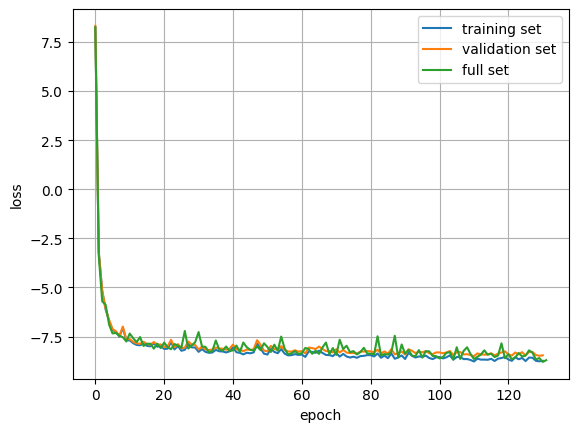

In [11]:
latent = CentBeta13(input_dim=n_summaries, B=5)
bijector = Chain(
    ShiftBounds(jnp.array(df_total[summary_labels].min(axis=0)), jnp.array(df_total[summary_labels].max(axis=0)), B=4),
    RollingSplineCoupling(n_summaries, B=5, n_conditions=n_params, hidden_dim=128),
)

flow = Flow(
    data_columns=summary_labels, 
    conditional_columns=params, 
    latent=latent,
    bijector=bijector,
)

# train with validation set and early stopping
loss_train, loss_val = flow.train(df_train, df_val, epochs=1000, patience=20, best_params=True, verbose=False, progress_bar=True)

# train on all of the data
flow = Flow(
    data_columns=summary_labels, 
    conditional_columns=params, 
    latent=latent,
    bijector=bijector,
)
n_epochs = len(loss_train)
loss_all = flow.train(df_total, epochs=n_epochs, verbose=False, progress_bar=True)

# plot
fig, ax = plt.subplots()
ax.plot(loss_train, label="training set")
ax.plot(loss_val, label="validation set")
ax.plot(loss_all, label="full set")
ax.set(xlabel="epoch", ylabel="loss")
ax.legend()
ax.grid(True)

### MCMC

In [12]:
obs_dfs = [obs_df_with, obs_df_without]
labels = [f"{n_steps}_flow_likelihood_with_survey_sys", f"{n_steps}_flow_likelihood_without_survey_sys"]

for obs_df, label in zip(obs_dfs, labels):
    def log_likelihood(X): 
        # convert to dataframe
        X = pd.DataFrame(X, columns=params)
        X = X.join(obs_df, how="cross")

        # evaluate the normalizing flow
        log_prob = flow.log_prob(X)

        # enforce the prior
        log_prob = prior.log_posterior(X.loc[:,params], log_prob, params=params, conf=None)

        return log_prob
    
    chain = mcmc.run_emcee(
        log_likelihood,
        params,
        out_dir=out_dir,
        label=label,
        n_walkers=2048,
        n_steps=500,
    )

23-08-04 00:38:07      mcmc.py INF   Initial values in prior: True 


100%|██████████| 500/500 [04:52<00:00,  1.71it/s]

23-08-04 00:44:12      mcmc.py INF   Initial values in prior: True 



100%|██████████| 500/500 [04:57<00:00,  1.68it/s]


### plot

  0%|          | 0/6 [00:00<?, ?it/s]

  0%|          | 0/6 [00:00<?, ?it/s]

  0%|          | 0/6 [00:00<?, ?it/s]

23-08-04 00:50:09  plotting.py WAR   Not saving the plot 


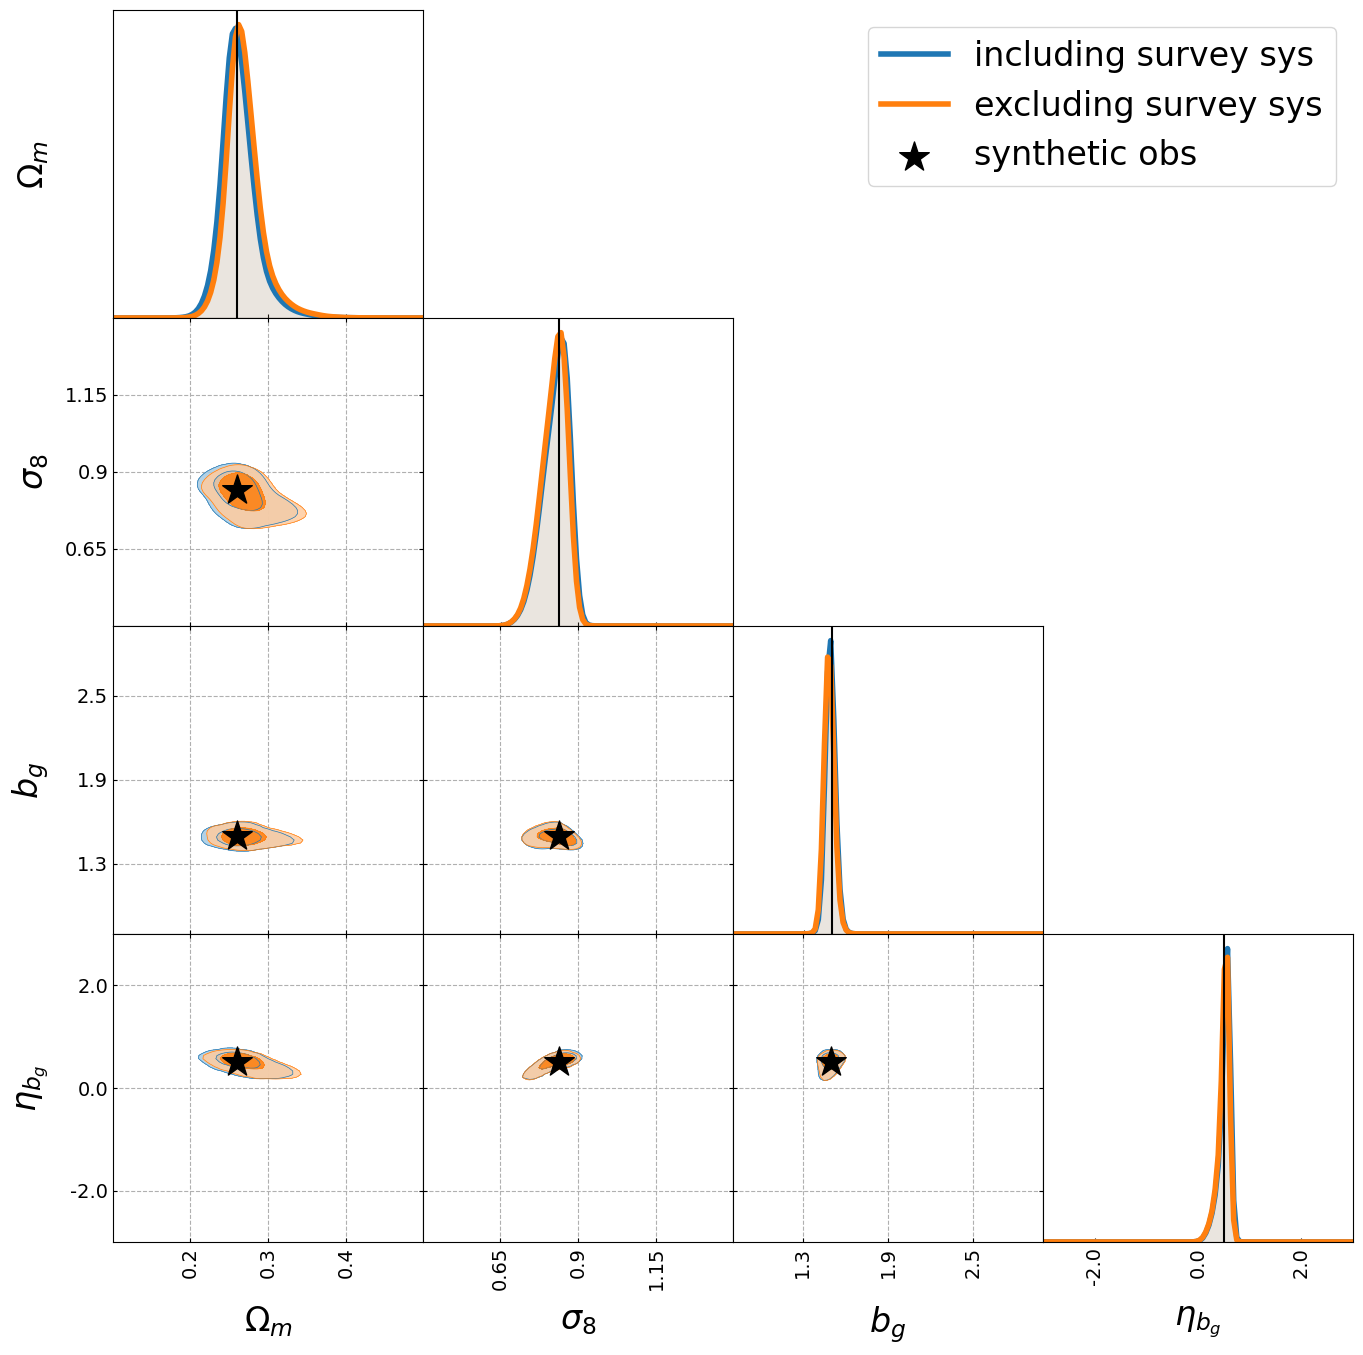

In [14]:
chains = [
    np.load(os.path.join(base_dir, model_dir, f"chain_{label}.npy")) for label in labels
]

legend_labels = [
    "including survey sys",
    "excluding survey sys",
]

plotting.plot_chains(
    chains, 
    params, 
    # out_dir=out_dir, 
    out_dir=None, 
    out_file=f"contours_{n_steps}_survey_sys.png",
    labels=legend_labels,
)